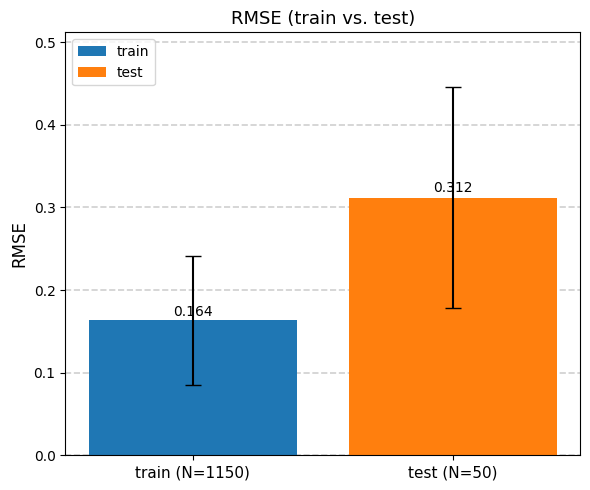

In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

CSV_PATH = "SUMMARY__Tin10_Tout10.csv"   # 改成你的路径

# 读取
df = pd.read_csv(CSV_PATH)

# 只保留关心列
cols_need = ["dataset_name", "rmse_mean", "rmse_var", "N"]
for c in cols_need:
    if c not in df.columns:
        raise ValueError(f"CSV缺少列: {c}")

# 解析 split(train/test) + 简洁标签
def parse_split(name: str):
    name = str(name).lower()
    if "_train_" in name:
        return "train"
    if "_test_" in name:
        return "test"
    # 兜底：看末尾是否有 train/test
    if re.search(r"(?:^|_)train(?:_|$)", name):
        return "train"
    if re.search(r"(?:^|_)test(?:_|$)", name):
        return "test"
    return "other"

df["split"] = df["dataset_name"].apply(parse_split)

# 只取 train/test 两类
df = df[df["split"].isin(["train", "test"])].copy()

# 排序（train 在前）
order = {"train": 0, "test": 1}
df = df.sort_values(by="split", key=lambda s: s.map(order)).reset_index(drop=True)

# x 轴标签：train (N=1150) / test (N=50)
df["xlabel"] = df.apply(lambda r: f"{r['split']} (N={int(r['N'])})", axis=1)

# 数值型
df["rmse_mean"] = pd.to_numeric(df["rmse_mean"], errors="coerce")
df["rmse_var"]  = pd.to_numeric(df["rmse_var"],  errors="coerce")

# 误差棒：用 std = sqrt(var)。如果为NaN就不画
y = df["rmse_mean"].to_numpy(dtype=float)
yerr = np.sqrt(df["rmse_var"].to_numpy(dtype=float))
yerr = None if np.isnan(yerr).all() else yerr

# 颜色：train/test
color_map = {"train": "#1f77b4", "test": "#ff7f0e"}  # 你可以换
colors = [color_map[s] for s in df["split"]]

# 画图
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(df))
bars = ax.bar(x, y, yerr=yerr, capsize=6, color=colors, edgecolor="none")

# 网格线（横向）
ax.set_axisbelow(True)
ax.grid(axis="y", which="major", linestyle="--", linewidth=1.2, alpha=0.6)

# 轴标签/刻度
ax.set_xticks(x)
ax.set_xticklabels(df["xlabel"], fontsize=11)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("RMSE (train vs. test)", fontsize=13)

# y 轴范围留点余量
ymax = np.nanmax(y + (yerr if yerr is not None else 0))
ax.set_ylim(0, ymax * 1.15)

# 数值标注在柱顶
for xi, yi in zip(x, y):
    if np.isfinite(yi):
        ax.text(xi, yi * 1.01, f"{yi:.3f}", ha="center", va="bottom", fontsize=10)

# 图例
handles = [plt.Rectangle((0,0),1,1, color=color_map["train"], ec="none", label="train"),
           plt.Rectangle((0,0),1,1, color=color_map["test"],  ec="none", label="test")]
ax.legend(handles=handles, loc="upper left")

plt.tight_layout()
plt.show()
# 如需保存：plt.savefig("rmse_train_vs_test.png", dpi=200, bbox_inches="tight")

